In [2]:
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam, AdamW
from torch.utils.data import Dataset, DataLoader
import pickle as pkl
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import root_mean_squared_error
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import os
import json

# quick hack for now
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [3]:
# note that here, nit using lagged/rolled features because only need to insert the values in
# previous window!\
df = pd.read_csv('../data/processed/hourly_usage_cleaned.csv')

In [4]:
# set index with multiindex
df.set_index(['client_id', 'datetime'], inplace=True)

In [5]:
# create time based features
datetimes = pd.to_datetime(df.index.get_level_values('datetime'))

# create both sin and cos so that 
df['hour_sin'] = np.sin(2*np.pi*datetimes.hour/24)
df['hour_cos'] = np.cos(2*np.pi*datetimes.hour/24)

df['day_sin'] = np.sin(2*np.pi*datetimes.dayofweek/7)
df['day_cos'] = np.cos(2*np.pi*datetimes.dayofweek/7)

df['month_sin'] = np.sin(2*np.pi*datetimes.hour/12)
df['month_cos'] = np.cos(2*np.pi*datetimes.hour/12)


In [6]:
# split data into train, validation and holdout test, with 70, 10, 20 split
min_date = datetimes.min()
max_date = datetimes.max()

validation_cutoff = min_date + 0.7*(max_date - min_date)
test_cutoff = min_date + 0.8*(max_date - min_date)

# split the data
df_train = df[datetimes < validation_cutoff]
df_validation = df[(datetimes > validation_cutoff) & (datetimes < test_cutoff)]
df_test = df[datetimes > test_cutoff]

In [7]:
# fit scaler to train data nd use to transform all sets
# do global scaling (doing per sequence would remove magnitude info that embeddings would no 
# longer be able to learn)
scaler = StandardScaler().fit(df_train)

# use to transform train, test, validate data sets (and into a tensor format)
data_train_preprocesed = torch.tensor(scaler.transform(df_train), dtype=torch.float32)
data_validate_preprocesed = torch.tensor(scaler.transform(df_validation), dtype=torch.float32)
data_test_preprocesed = torch.tensor(scaler.transform(df_test), dtype=torch.float32)

In [8]:
# precompute client ids so not recomputing at every timestep.
client_ids_train = df_train.index.get_level_values('client_id')
client_ids_validate = df_validation.index.get_level_values('client_id')
client_ids_test = df_test.index.get_level_values('client_id')

# create a list of client ids that are in all training, testing and validation (train misses some that are in validate/test)
client_ids_in_all_data = client_ids_train.intersection(client_ids_validate).intersection(client_ids_test)

In [9]:
# create array to randomly sample 100 clients from the list of all clients (and for random stride in time - see later)
# need to ensure no repeat samples
num_clients = 100
rng = np.random.default_rng(seed=42)

# create random sample from client ids, ensuring no duplicates
random_client_subset = np.sort(rng.choice(client_ids_in_all_data, size=num_clients, replace=False))

# create dictionary mapping client_id to a 'embedding index', so can get index corresponding to id to use in 
# embedding layer
client_embedding_index_dict = {rand_client: i for i, rand_client in enumerate(random_client_subset)}

In [10]:
# create dictionaries of data where key represents client and value all data for that client
# (that will access during training)

# get client data in training, validation and test for the random subset of clients to be chosen
data_train_dict = {client_id: data_train_preprocesed[client_ids_train == client_id] for client_id in random_client_subset}
data_validate_dict = {client_id: data_validate_preprocesed[client_ids_validate == client_id] for client_id in random_client_subset}
data_test_dict = {client_id: data_test_preprocesed[client_ids_test == client_id] for client_id in random_client_subset}

In [11]:
# create an index map for all possible starting indicies for sequence

# sequence length
seq_length = 24*7
# total valid number starting indexes (and thus valid number of sequences)
tot_num_start_indx_train = [data.shape[0] - seq_length for client_id, data in data_train_dict.items()]
tot_num_start_indx_validate = [data.shape[0] - seq_length for client_id, data in data_validate_dict.items()]
tot_num_start_indx_test = [data.shape[0] - seq_length for client_id, data in data_test_dict.items()]

In [12]:
# taking random stride across sequences in training, to reduce compute while ensuring sufficient sampling across all times
# note that fixed with random seed
train_stride_low = 12
train_stride_high = 23
# for validation, use fixed stride for reproducibility
validate_stride = 12
# for test using stride of 1 so can get full forecast across all time points, to simulate production
test_stride = 1

# random goes isnide loop here so that random stride at every iteration
index_map_train = [(client_id, start_index) for i, client_id in enumerate(random_client_subset) for start_index in range(0, tot_num_start_indx_train[i], rng.integers(low=train_stride_low, high=train_stride_high, size=1)[0])]
index_map_validate = [(client_id, start_index) for i, client_id in enumerate(random_client_subset) for start_index in range(0, tot_num_start_indx_validate[i], validate_stride)]
index_map_test = [(client_id, start_index) for i, client_id in enumerate(random_client_subset) for start_index in range(0, tot_num_start_indx_test[i], test_stride)]

In [13]:
# create Dataset class to retrieve the sequences, given an index

class SeqExtractionDataSet(Dataset):

    def __init__(self, data_dict, idx_map, seq_length=24*7):
        
        # set idx map, which use to get total number of samples
        # set data dict which extract the samples from
        # set the sequence length which gives the length of each sample X_seq
        self.data_dict = data_dict
        self.idx_map = idx_map
        self.seq_length = seq_length


    def __getitem__(self, idx):
        """ take integer idx from the dataloader and return the features at all time points in 
        context window seq_length (X_seq), along with the target (y_seq) and corresponding client_id EMBEDDING
         INDEX (not the id itself).
         
        if mode set to 'train' then extracts from training set. 'validate' extracts from validation set. 'test' extracts 
        from the test set. Else gives an error.

        Note use of intermediate index map to extract sequences on a per client basis """

        # idx is a numeric integer returned by the dataloader (which it creates using length of all samples)
        # so use this integer to extract a corresponding index from index map, for a sequence
        # then extract the client_id and starting index of sequence from the corresopnding tuple
        client_id = self.idx_map[idx][0]
        seq_start_idx = self.idx_map[idx][1]

        # and to extract the corresponding context window and target
        X_seq = self.data_dict[client_id][seq_start_idx: seq_start_idx + self.seq_length, :]
        # for target, just want usage only
        y_seq = self.data_dict[client_id][seq_start_idx + self.seq_length, 0]

        # assume that the sequences are already in torch tensor format. client id embedding index 
        # will be used as lookup in embedding matrix so store in long format
        # NOTE: not storing client id itself here, but the index used to access its embedding in 
        # embedding matrix
        
        return X_seq, y_seq, torch.tensor(client_embedding_index_dict[client_id], dtype=torch.long)


    def __len__(self):
        """ returns the total number of samples in the Dataset. Used by dataloader """

        #TODO: need more tests for shapes compatibility etc.
        return len(self.idx_map)

In [14]:
# now create instance of the dataset for train, test, and validate
dataset_train = SeqExtractionDataSet(data_dict=data_train_dict, idx_map=index_map_train, seq_length=seq_length)
dataset_validate = SeqExtractionDataSet(data_dict=data_validate_dict, idx_map=index_map_validate, seq_length=seq_length)
dataset_test = SeqExtractionDataSet(data_dict=data_test_dict, idx_map=index_map_test, seq_length=seq_length)

batch_size = 32

# and corresponding dataloaders. Fine to shuffle because using sequences here rather than time points
dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True, drop_last=True)
dataloader_validate = DataLoader(dataset_validate, batch_size=32, shuffle=True, drop_last=True)
# don't bother shuffling test as not computing the loss here
dataloader_test = DataLoader(dataset_test, batch_size=32, shuffle=False, drop_last=True)

In [15]:
# number of features
n_features = len(df_train.columns)
# embedding dim size
embedding_dim = 8
# hidden size in LSTM
hidden_size = 10
# num embeddings - use those in random subset
num_embeddings = len(random_client_subset)

In [16]:
# now implement the LSTM class

# for now keep vanilla with no multiple layers
class LSTMDemand(nn.Module):

    def __init__(self, n_features, num_embeddings, embedding_dim=8, hidden_size=8):

        super().__init__()

        # embedding layer to capture client specific info
        # note this is a look up table which stores the embeddings.
        # with embedding dim embeddings for each client
        #  These embeddings are concatenated with features in the forwards pass

        # create an embedding equal to max number of clients (note that some clients are eliminated)
        # but for simplicity for now, just leave their weights unchanged (and could set to zero later)
        self.embedding = nn.Embedding(num_embeddings=num_embeddings, embedding_dim=embedding_dim)

        # LSTM layer
        self.lstm = nn.LSTM(input_size=n_features + embedding_dim, hidden_size=hidden_size, batch_first=True)

        # final fully connected layer, taking hidden states and producing output value for next point in time
        self.fc = nn.Linear(in_features=hidden_size, out_features=1)
    

    def forward(self, input_seq_batch, client_ids_batch):
        
        # first need to get embeddings corresponding to client id from the input.
        # use the nn.embedding lookup, inserting client ids (which correspond to rows in the lookup matrix)
        # note minus one for python indexing
        # by default has size (batch, embedding_dim). Here place axis size 1 inbetween these, for seq dim,
        # so that shape matches that of input seq_batch
        client_embed = self.embedding(client_ids_batch).unsqueeze(1)

        # repeat embeddings across all time points in the sequence dim
        client_embed_repeated = client_embed.repeat(1, seq_length, 1)
        # to then column stack those embeddings with the features
        # concat along the features/embedding axis
        input_seq_batch_concat = torch.cat((input_seq_batch, client_embed_repeated), axis=2)

        # after this now have tensor of shape (batch_size, seq_length, num_features + embedding_dim)
        # only take first output
        lstm_output, _ = self.lstm(input_seq_batch_concat)

        # and final feedforwards layer. Note need to extract the output from the final timestep in sequence (because)
        # output form LSTM returns hidden state of final LSTM layer at all sequence timesteps
        return self.fc(lstm_output[:, -1, :]).squeeze(-1)


model = LSTMDemand(n_features=n_features, embedding_dim=embedding_dim, num_embeddings=num_embeddings, hidden_size=hidden_size)

In [17]:
# set up the optimiser
# implementing weight decay (to ensure inputs into LSTM do not become too large - helsp avoid vanishing gradient issue
# at the input, forget and output gates)

#  AdamW with more consistent regularisation accross weights
optimiser = AdamW(params=model.parameters(), lr=0.001, weight_decay=0.001)

# use MSE for criterion for training
criterion = nn.MSELoss()

In [18]:
# create a class for early stopping

class EarlyStopping():

    def __init__(self, patience, delta):
        
        self.patience = patience
        self.delta = delta

        # track the model and epoch where the loss was last decreasing
        self.prev_dec_model = None
        self.prev_dec_epoch = None
        # track the previous loss, at every iteration of this class
        self.prev_loss = None
        # counts num iterations since loss last decreased
        self.no_improve_count = 0
        # flag to stop training if patience exceeded
        self.stop_training = False
    
    def check_early_stop(self, val_loss, model_state_dict, epoch):
        
        # need to save version with best weights and biases, while using previous loss
        # as metric to increment counter
        # test using previous loss where loss decreased, rather than the minimum loss
        if self.prev_loss is None or val_loss < self.prev_loss - self.delta:

            # if model is improving, reset the counter
            # and the counter
            self.no_improve_count = 0

            # update saved model (as this is the weights and biases from last model where loss had decreased) 
            self.prev_dec_model = model_state_dict
            self.prev_dec_epoch = epoch

            # then set the previous loss to this one
            self.prev_loss = val_loss
        else:
            # otherwise increment the counter
            self.no_improve_count += 1

            # set the previous loss to this one
            self.prev_loss = val_loss

            # if exceeds patience, signal to end the run
            if self.no_improve_count >= self.patience:
                self.stop_training = True

In [19]:
EPOCHS = 200
# create instnace of early stopping class
early_stop_checker = EarlyStopping(patience=5, delta=0.001)

In [78]:
# and now the main training loop

# empty list for the average validation and training losses (for later plotting)
loss_val_averages_list = []
loss_train_averages_list = []

# first loop over epochs
for epoch in range(EPOCHS):

    print(f'\n starting epoch {epoch}')
    losses_train = []
    model.train()
    
    for batch_idx, (X_seqs, labels, client_ids) in enumerate(dataloader_train):

        # do forwards pass
        predictions = model.forward(X_seqs, client_ids)

        # compute loss
        loss = criterion(predictions, labels)
        loss.backward()

        # step forwards
        optimiser.step()
        optimiser.zero_grad()
    
        # append batch training loss to list
        with torch.no_grad():
            losses_train.append(loss.item())

    print(f'training at epoch {epoch} completed')
    
    with torch.no_grad():
        # after training completed, append batch-averaged training loss to list
        loss_train_averages_list.append(np.mean(losses_train))

    # at every other epoch
    if epoch % 2 == 0:  #epoch > 10 and 
        
        # list of losses which will average over (reset at each validation loop)
        losses_val = []
        # at end of epoch, now evaluate the validation loss
        model.eval()
        with torch.no_grad():
            for batch_idx, (X_seqs_val, labels_val, client_ids_val) in enumerate(dataloader_validate):

                preds_val = model(X_seqs_val, client_ids_val)
                losses_val.append(criterion(preds_val, labels_val).item())
            
            # after going through batches average loss across them
            losses_val_average = np.mean(losses_val)

            # and evaluate early stopping
            early_stop_checker.check_early_stop(val_loss=losses_val_average, epoch=epoch, model_state_dict=model.state_dict())

            # if time to stop then do so and restore best performing weights and biases
            if early_stop_checker.stop_training is True:
                # print(f'early stopping criterion reached at {epoch} epochs. restoring to weights and biases at {early_stop_checker.best_model_epoch} epochs')
                print(f'early stopping criterion reached at {epoch} epochs. restoring to weights and biases at {early_stop_checker.prev_dec_epoch} epochs')

                # model.load_state_dict(early_stop_checker.best_model)
                model.load_state_dict(early_stop_checker.prev_dec_model)

                # and save the mode state dictionary
                with open('../models/LSTM_AdamW.pkl', 'wb') as f:
                    pkl.dump(early_stop_checker.prev_dec_model, f)
                
                # then end training
                break
                
            # append average loss to its own list for plotting later
            loss_val_averages_list.append(losses_val_average)


 starting epoch 0
training at epoch 0 completed

 starting epoch 1
training at epoch 1 completed

 starting epoch 2
training at epoch 2 completed

 starting epoch 3
training at epoch 3 completed

 starting epoch 4
training at epoch 4 completed

 starting epoch 5
training at epoch 5 completed

 starting epoch 6
training at epoch 6 completed

 starting epoch 7
training at epoch 7 completed

 starting epoch 8
training at epoch 8 completed

 starting epoch 9
training at epoch 9 completed

 starting epoch 10
training at epoch 10 completed

 starting epoch 11
training at epoch 11 completed

 starting epoch 12
training at epoch 12 completed

 starting epoch 13
training at epoch 13 completed

 starting epoch 14
training at epoch 14 completed

 starting epoch 15
training at epoch 15 completed

 starting epoch 16
training at epoch 16 completed

 starting epoch 17
training at epoch 17 completed

 starting epoch 18
training at epoch 18 completed

 starting epoch 19
training at epoch 19 completed


In [ ]:
# save model weights manually if not already done
with open('../models/LSTM_AdamW.pkl', 'wb') as f:
                    pkl.dump(early_stop_checker.prev_dec_model, f)

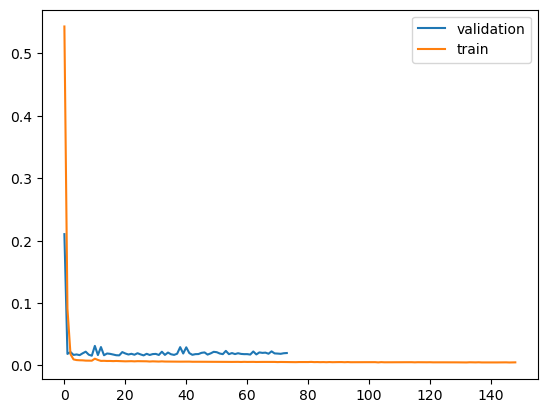

In [ ]:
# plot the loss (validation loss computed once every 2 epcohs currently)

plt.plot(loss_val_averages_list, label='validation')
plt.plot(loss_train_averages_list, label='train')
plt.legend()
plt.savefig('../plots/train_val_loss_after_200_epochs_adamw')
plt.show()

In [ ]:
# NOW FOR EVALUATION with testing data

model.eval()

# create dictionaries to store the predictions and corresponding labels for each client embedding id
preds_dict = defaultdict(list)
labels_dict = defaultdict(list)

for batch_idx, (X_seqs_test, labels_test, client_embed_ids_test) in enumerate(dataloader_test):
    
    # run the sequence and client id through the LSTM
    y_preds = model(X_seqs_test, client_embed_ids_test)

    # get unique embedding index of clients in each batch
    clients_embed_index_unique = client_embed_ids_test.unique().detach().numpy()

    # batches may have overlap of client ids, so split the data across batch idx dimension if that happens
    # if only one client, then append to that clients dictionar
    if len(clients_embed_index_unique) == 1:

        # convert to int for indexing into dictionary
        clients_embed_index_unique = int(clients_embed_index_unique)

        # assign to dictionary
        preds_dict[clients_embed_index_unique] += list(y_preds.detach().numpy().flatten())
        labels_dict[clients_embed_index_unique] += list(labels_test.detach().numpy().flatten())
    elif len(clients_embed_index_unique) == 2:

        # need to split the data where client id changes
        # get the index of first instance of other client id
        index_of_change = np.where(client_embed_ids_test == clients_embed_index_unique[1])[0][0]
        # then use to split data and save to dictionary
        preds_dict[clients_embed_index_unique[0]] += list(y_preds[:index_of_change].detach().numpy().flatten())
        labels_dict[clients_embed_index_unique[0]] += list(labels_test[:index_of_change].detach().numpy().flatten())

        preds_dict[clients_embed_index_unique[1]] += list(y_preds[index_of_change:].detach().numpy().flatten())
        labels_dict[clients_embed_index_unique[1]] += list(labels_test[index_of_change:].detach().numpy().flatten())

    else:
        raise Exception(f'incompatible number of client ids within the batch, totalling {len(clients_embed_index_unique)}')

C:\Users\Flynn\AppData\Local\Temp\ipykernel_320\3244469057.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  clients_embed_index_unique = int(clients_embed_index_unique)


In [ ]:
# for each client, check the lengths of their prediction array
[len(x) for client_id, x in preds_dict.items()]
# last client has 20 less entries but otherwise all the same

[6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6845,
 6825]

In [ ]:
# get mean and variance used to scale the hourly usage
mean_to_scale = scaler.mean_[0]
var_to_scale = scaler.var_[0]

# for each client, get scaled labels and predictions
preds_dict_unscaled = {client_id: np.array(preds_dict[client_id]) * var_to_scale**0.5 + mean_to_scale for client_id in preds_dict.keys()}
labels_dict_unscaled = {client_id: np.array(labels_dict[client_id]) * var_to_scale**0.5 + mean_to_scale for client_id in labels_dict.keys()}

# and compute the mean usage for each client
mean_usages = {client_id: labels_dict_unscaled[client_id].mean() for client_id in labels_dict.keys()}

# and the root mean sqaured error normalised by the mean test data usage
nrmse_dict = {int(client_id): root_mean_squared_error(preds_dict_unscaled[client_id], labels_dict_unscaled[client_id])/mean_usages[client_id] for client_id in preds_dict.keys()}

In [ ]:
# summary staistics for nrmse

summary_dict = {
'mean_nrmse': np.mean(list(nrmse_dict.values())),
'std_nrmse': np.std(list(nrmse_dict.values())),
'max_nrmse': np.max(list(nrmse_dict.values())),
'min_nrmse': np.min(list(nrmse_dict.values())),
}

# save predictions and labels, and initial performance metrics
with open('../data/processed/preds_LSTM_test.pkl', 'wb') as f:
    pkl.dump(preds_dict_unscaled, f)

with open('../data/processed/labels_LSTM_test.pkl', 'wb') as f:
    pkl.dump(labels_dict_unscaled, f)

with open('../logs/nrmse_across_clients_LSTM', 'w') as f:
    json.dump(nrmse_dict, f, indent=4)

with open('../logs/nrmse_all_client_sum_LSTM', 'w') as f:
    json.dump(summary_dict, f, indent=4)

# mean nrmse of 0.16 (i.e., error of 16% relative to the mean usage)

In [ ]:
# here can see that every client has data for all dates from testing data
# given that earlier, every client has hourly data in this period with no nans, will assume that predictions at given time poiny
# correspond to datetime then, up to max datetime - sequence length
# NOTE: where removing bad data in future, will need to account for this!
min_dates = df_test[df_test.index.get_level_values('client_id').isin(random_client_subset)].reset_index().groupby('client_id')['datetime'].min()
min_dates.unique()

# so just use datetime range form testing df
datetime_for_tests = pd.to_datetime(df_test.index.get_level_values('datetime').unique())
datetime_for_tests = datetime_for_tests[:len(datetime_for_tests) - seq_length]

DatetimeIndex(['2014-03-14 20:00:00', '2014-03-14 21:00:00',
               '2014-03-14 22:00:00', '2014-03-14 23:00:00',
               '2014-03-15 00:00:00', '2014-03-15 01:00:00',
               '2014-03-15 02:00:00', '2014-03-15 03:00:00',
               '2014-03-15 04:00:00', '2014-03-15 05:00:00',
               ...
               '2014-12-24 15:00:00', '2014-12-24 16:00:00',
               '2014-12-24 17:00:00', '2014-12-24 18:00:00',
               '2014-12-24 19:00:00', '2014-12-24 20:00:00',
               '2014-12-24 21:00:00', '2014-12-24 22:00:00',
               '2014-12-24 23:00:00', '2014-12-25 00:00:00'],
              dtype='datetime64[ns]', name='datetime', length=6845, freq=None)

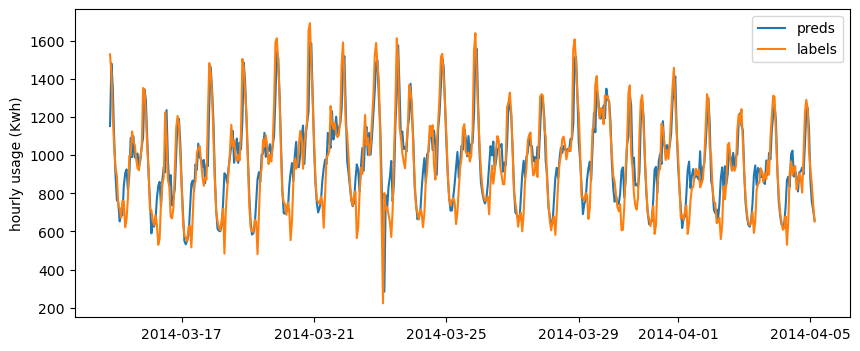

In [ ]:
# quick plot of time series

plt.figure(figsize=(10, 4))

idx_to_plot = slice(4*128)
client_to_plot = 10

plt.plot(datetime_for_tests[idx_to_plot], preds_dict_unscaled[client_to_plot][idx_to_plot], label='preds')
plt.plot(datetime_for_tests[idx_to_plot], labels_dict_unscaled[client_to_plot][idx_to_plot], label='labels')
plt.ylabel('hourly usage (Kwh)')
plt.legend()
plt.show()